# Handling Class Imbalance

Customer churn datasets are typically imbalanced, with significantly more non-churning customers than churning customers.

A model trained on imbalanced data may achieve high accuracy while failing to identify many customers who are likely to churn.

In this notebook, two popular techniques are explored to address class imbalance:

- Class Weight
- SMOTE (Synthetic Minority Over-sampling Technique)

The performance of these approaches is compared with the baseline models using:

- Accuracy
- Precision
- Recall
- F1-Score
- ROC-AUC

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from imblearn.over_sampling import SMOTE

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

## Load Processed Dataset

In [2]:
X_train = pd.read_csv("X_train_processed.csv")
X_test = pd.read_csv("X_test_processed.csv")

y_train = pd.read_csv("y_train.csv").squeeze()
y_test = pd.read_csv("y_test.csv").squeeze()

print("Training Shape :", X_train.shape)
print("Testing Shape  :", X_test.shape)

Training Shape : (5634, 50)
Testing Shape  : (1409, 50)


## Check Class Distribution

In [3]:
y_train.value_counts()

Churn Value
0    4139
1    1495
Name: count, dtype: int64

In [4]:
(y_train.value_counts(normalize=True)*100).round(2)

Churn Value
0    73.46
1    26.54
Name: proportion, dtype: float64

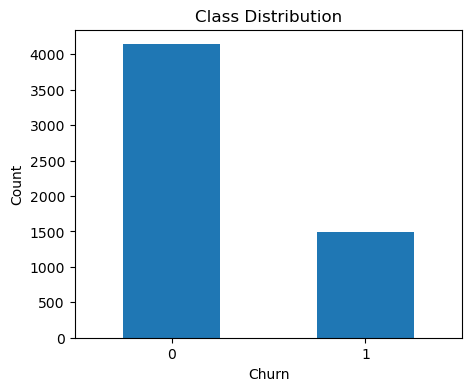

In [5]:
plt.figure(figsize=(5,4))

y_train.value_counts().plot(
    kind="bar"
)

plt.title("Class Distribution")

plt.xlabel("Churn")

plt.ylabel("Count")

plt.xticks(rotation=0)

plt.show()

## Apply SMOTE

In [9]:
smote = SMOTE(
    random_state=42
)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

## Check New Distribution

In [11]:
y_train_smote.value_counts()

Churn Value
0    4139
1    4139
Name: count, dtype: int64

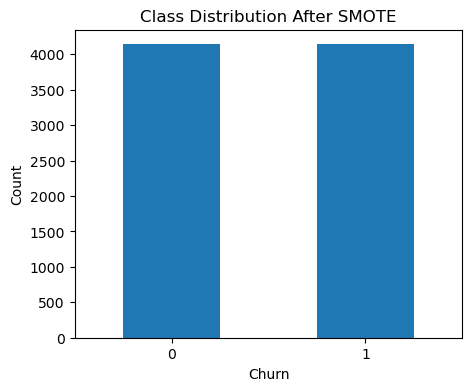

In [12]:
plt.figure(figsize=(5,4))

y_train_smote.value_counts().plot(
    kind="bar"
)

plt.title("Class Distribution After SMOTE")

plt.xlabel("Churn")

plt.ylabel("Count")

plt.xticks(rotation=0)

plt.show()

## Models with Class Weight

In [13]:
weighted_models = {

    "Logistic Regression": LogisticRegression(
        class_weight="balanced",
        max_iter=1000,
        random_state=42
    ),

    "Decision Tree": DecisionTreeClassifier(
        class_weight="balanced",
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        class_weight="balanced",
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ),

    "XGBoost": XGBClassifier(
        scale_pos_weight=
        (y_train==0).sum()/(y_train==1).sum(),
        random_state=42,
        eval_metric="logloss",
        n_jobs=-1
    )
}

## Train Weighted Models

In [14]:
weighted_results = []

for name, model in weighted_models.items():

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    y_prob = model.predict_proba(X_test)[:,1]

    weighted_results.append({

        "Model": name,

        "Accuracy": accuracy_score(y_test, y_pred),

        "Precision": precision_score(y_test, y_pred),

        "Recall": recall_score(y_test, y_pred),

        "F1 Score": f1_score(y_test, y_pred),

        "ROC AUC": roc_auc_score(y_test, y_prob)

    })

## Results

In [16]:
weighted_df = pd.DataFrame(weighted_results)

weighted_df = weighted_df.round(4)

weighted_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.7438,0.5114,0.7807,0.6180,0.8481
1,Decision Tree,0.7388,0.5082,0.4947,0.5014,0.6609
2,Random Forest,0.7913,0.6351,0.5027,0.5612,0.8427
3,XGBoost,0.7651,0.5483,0.6524,0.5958,0.8255


## Models for SMOTE

In [17]:
smote_models = {

    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42
    ),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ),

    "XGBoost": XGBClassifier(
        random_state=42,
        eval_metric="logloss",
        n_jobs=-1
    )
}

## Train on SMOTE Data

In [18]:
smote_results = []

for name, model in smote_models.items():

    model.fit(
        X_train_smote,
        y_train_smote
    )

    y_pred = model.predict(X_test)

    y_prob = model.predict_proba(X_test)[:,1]

    smote_results.append({

        "Model": name,

        "Accuracy": accuracy_score(y_test, y_pred),

        "Precision": precision_score(y_test, y_pred),

        "Recall": recall_score(y_test, y_pred),

        "F1 Score": f1_score(y_test, y_pred),

        "ROC AUC": roc_auc_score(y_test, y_prob)

    })

## Results

In [19]:
smote_df = pd.DataFrame(smote_results)

smote_df = smote_df.round(4)

smote_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.7509,0.5204,0.7834,0.6254,0.8461
1,Decision Tree,0.7289,0.4907,0.5642,0.5249,0.6763
2,Random Forest,0.7850,0.5957,0.5909,0.5933,0.8362
3,XGBoost,0.7828,0.5934,0.5775,0.5854,0.8356


## Compare Weighted vs SMOTE

In [20]:
comparison = pd.concat(

    [

        weighted_df.assign(Method="Class Weight"),

        smote_df.assign(Method="SMOTE")

    ],

    ignore_index=True

)

comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC,Method
0,Logistic Regression,0.7438,0.5114,0.7807,0.6180,0.8481,Class Weight
1,Decision Tree,0.7388,0.5082,0.4947,0.5014,0.6609,Class Weight
2,Random Forest,0.7913,0.6351,0.5027,0.5612,0.8427,Class Weight
3,XGBoost,0.7651,0.5483,0.6524,0.5958,0.8255,Class Weight
4,Logistic Regression,0.7509,0.5204,0.7834,0.6254,0.8461,SMOTE
5,Decision Tree,0.7289,0.4907,0.5642,0.5249,0.6763,SMOTE
6,Random Forest,0.7850,0.5957,0.5909,0.5933,0.8362,SMOTE
7,XGBoost,0.7828,0.5934,0.5775,0.5854,0.8356,SMOTE


## Visualization

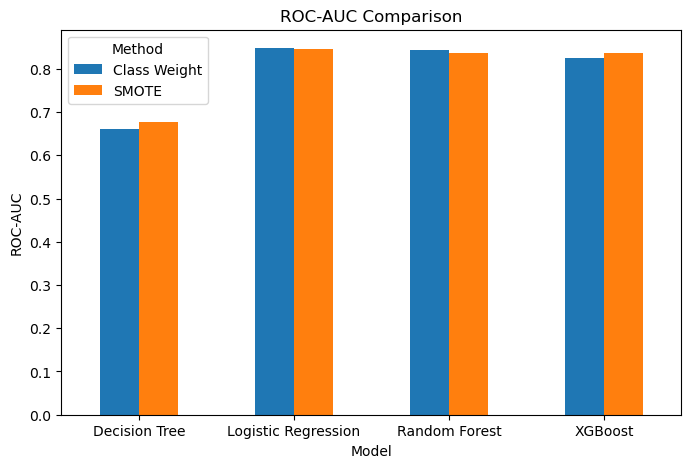

In [21]:
pivot = comparison.pivot(
    index="Model",
    columns="Method",
    values="ROC AUC"
)

pivot.plot(
    kind="bar",
    figsize=(8,5)
)

plt.ylabel("ROC-AUC")

plt.title("ROC-AUC Comparison")

plt.xticks(rotation=0)

plt.show()

## Save Results

In [23]:
comparison.to_csv(
    "class_imbalance_results.csv",
    index=False
)

print("Results Saved Successfully")

Results Saved Successfully


# Conclusion

The effect of handling class imbalance was evaluated using two different approaches:

- Class Weight
- SMOTE

Both methods were compared against the baseline models using Accuracy, Precision, Recall, F1-Score, and ROC-AUC.

The results help determine whether improving the representation of the minority class leads to better churn prediction without significantly sacrificing overall performance.

The best-performing approach will be selected for hyperparameter tuning in the next stage of the project.